In [18]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import json
import os
import random

# Enable inline plots
%matplotlib inline

# Set up base path
os.chdir(r"c:\Users\lydia\coding\image_seg\bbox_learn\bbox_learn")
base_path = "dataset"
print("Working directory:", os.getcwd())

Working directory: c:\Users\lydia\coding\image_seg\bbox_learn\bbox_learn


In [19]:
## 1. SMOKE5K Dataset (Human-Labeled Ground Truth)
# ~5,000 smoke images with pixel-level ground truth masks

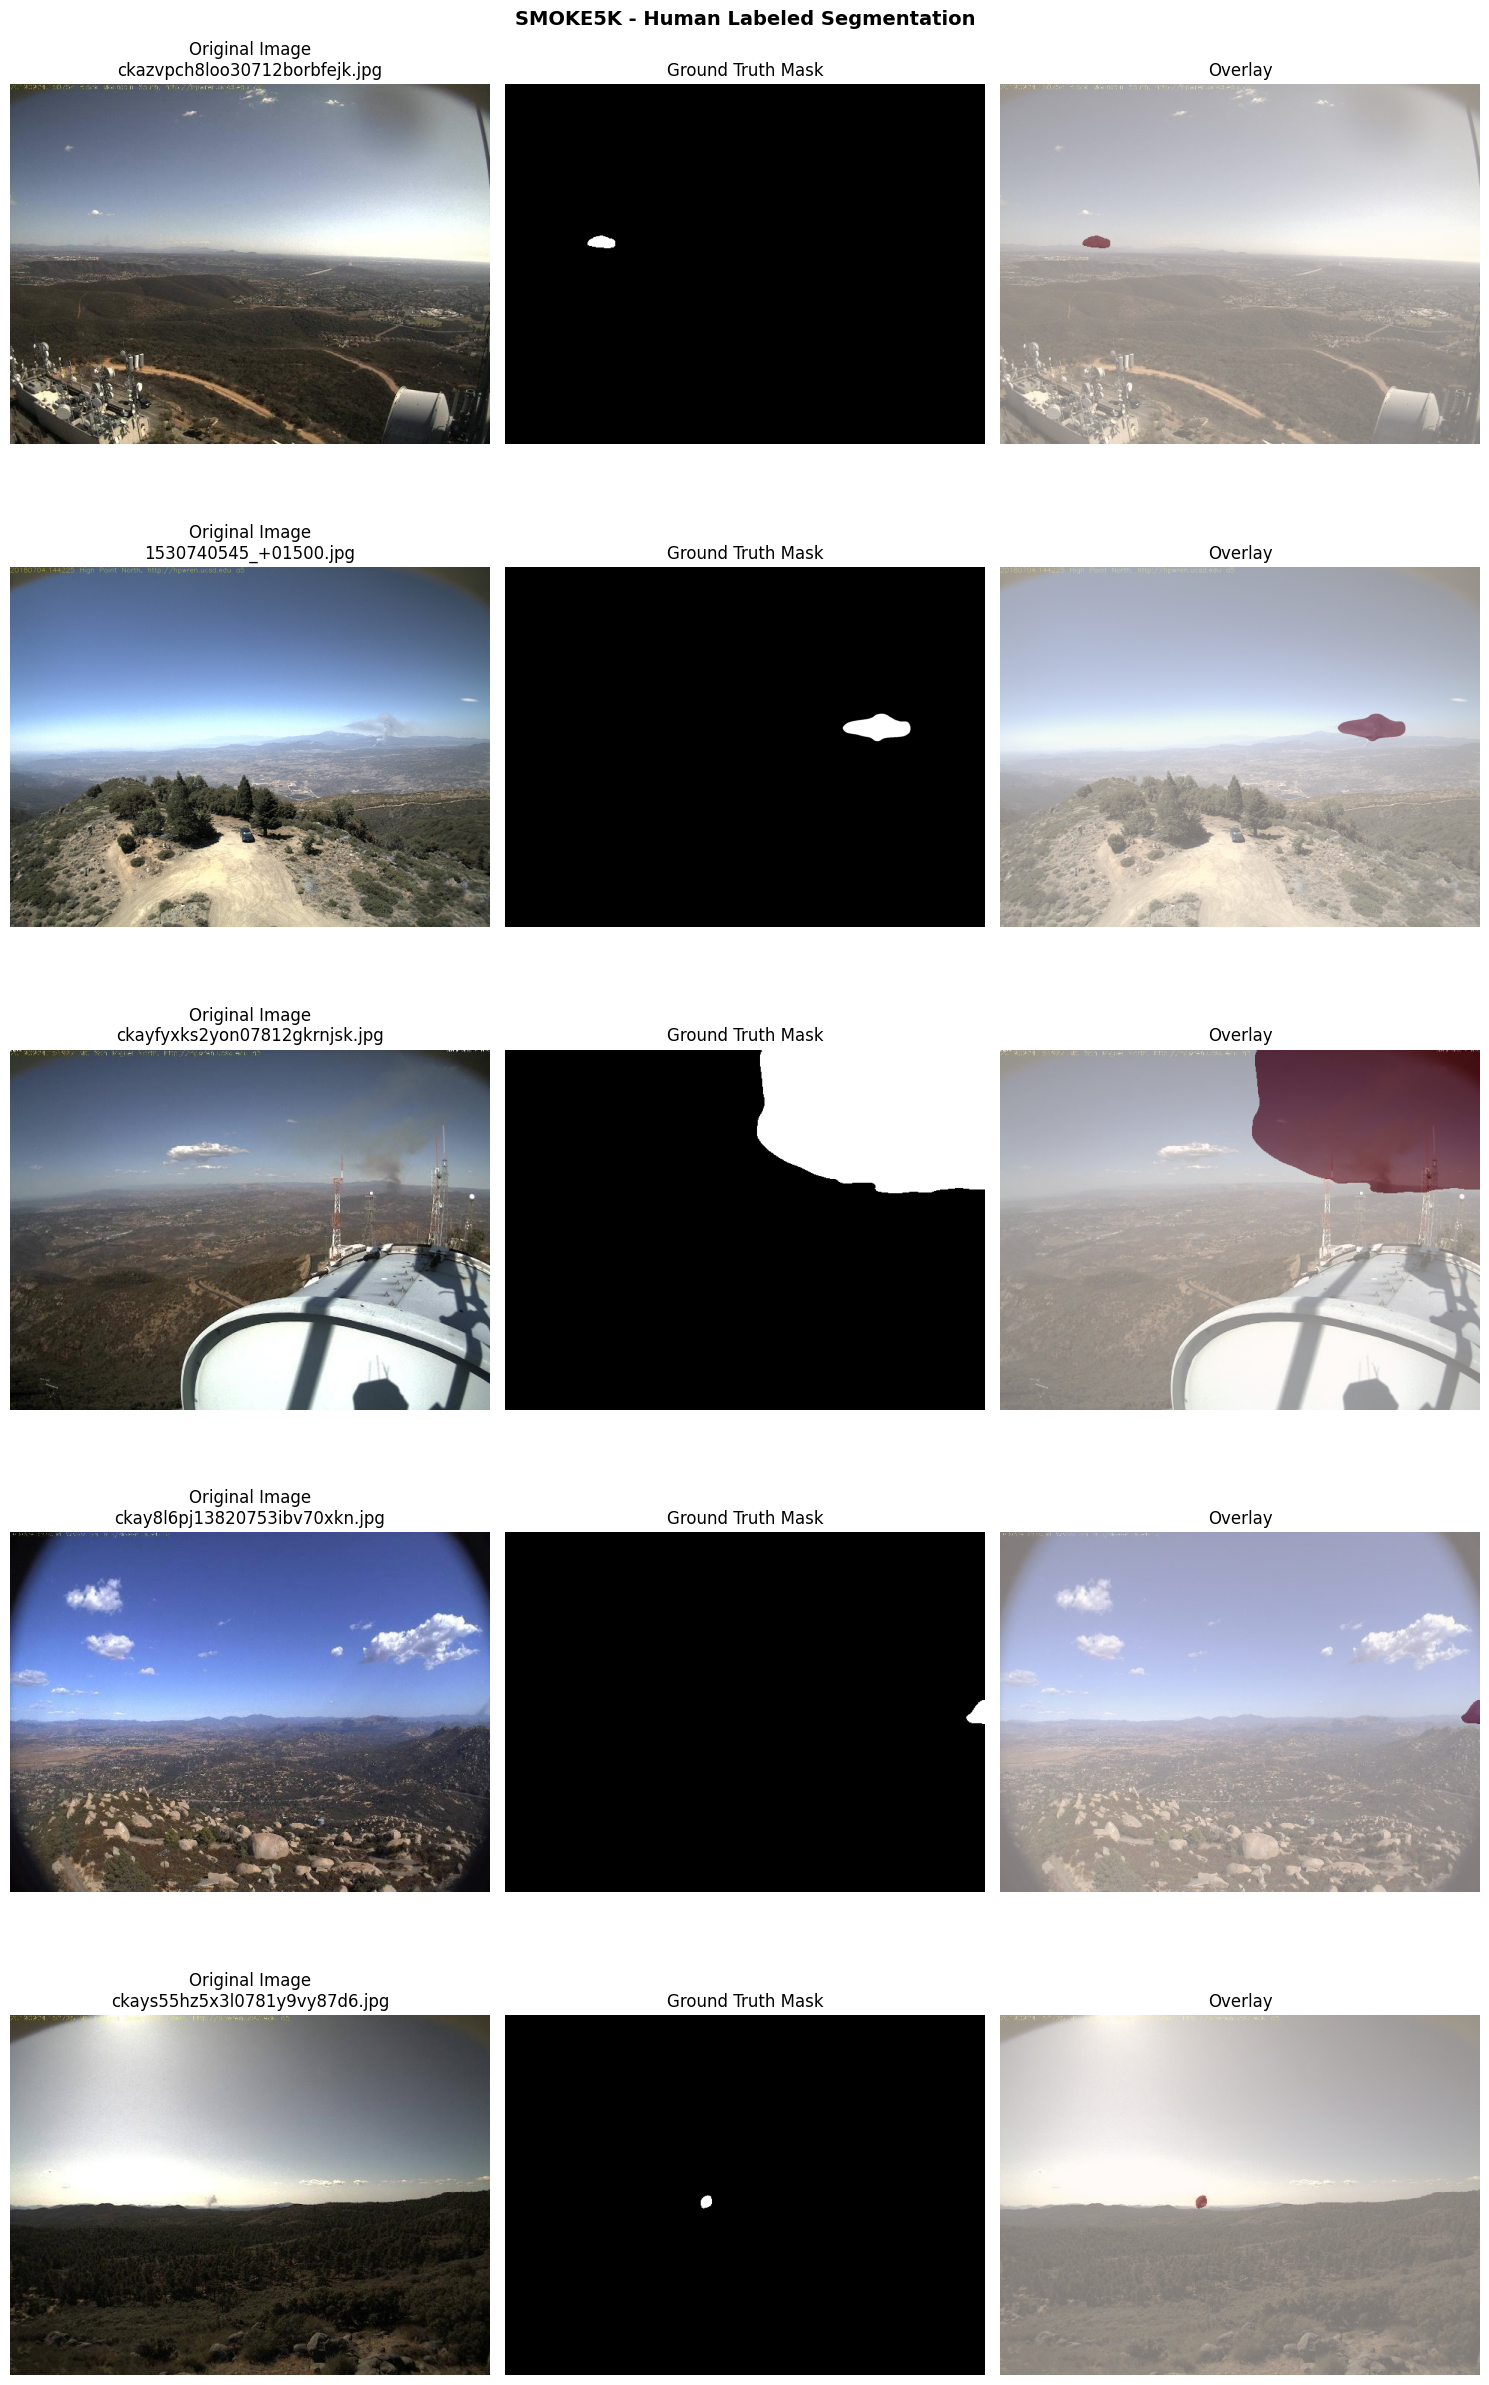

Total images in smoke5k/test: 400


In [26]:
# Smoke5k - Ground Truth Visualization
smoke5k_test_img_path = os.path.join(base_path, "smoke5k/test/img")
smoke5k_test_gt_path = os.path.join(base_path, "smoke5k/test/gt")
# Smoke5k - Ground Truth Visualization

random_img_index = [random.randint(0, len(os.listdir(smoke5k_test_img_path)) - 1) for _ in range(5)]

# Get a sample image
img_files = sorted(os.listdir(smoke5k_test_img_path))
sample_img_names = [img_files[i] for i in random_img_index]
sample_gt_names = [name.replace('.jpg', '.png') for name in sample_img_names]

imgs = [Image.open(os.path.join(smoke5k_test_img_path, name)) for name in sample_img_names]
gts = [Image.open(os.path.join(smoke5k_test_gt_path, name)) for name in sample_gt_names]
fig, axes = plt.subplots(5, 3, figsize=(15, 25))
for i in range(5):
    axes[i, 0].imshow(imgs[i])
    axes[i, 0].set_title(f"Original Image\n{sample_img_names[i]}")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(gts[i], cmap='gray')
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis('off')

    axes[i, 2].imshow(imgs[i])
    axes[i, 2].imshow(np.array(gts[i]), alpha=0.5, cmap='Reds')
    axes[i, 2].set_title("Overlay")
    axes[i, 2].axis('off')

plt.suptitle("SMOKE5K - Human Labeled Segmentation", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Total images in smoke5k/test: {len(img_files)}")

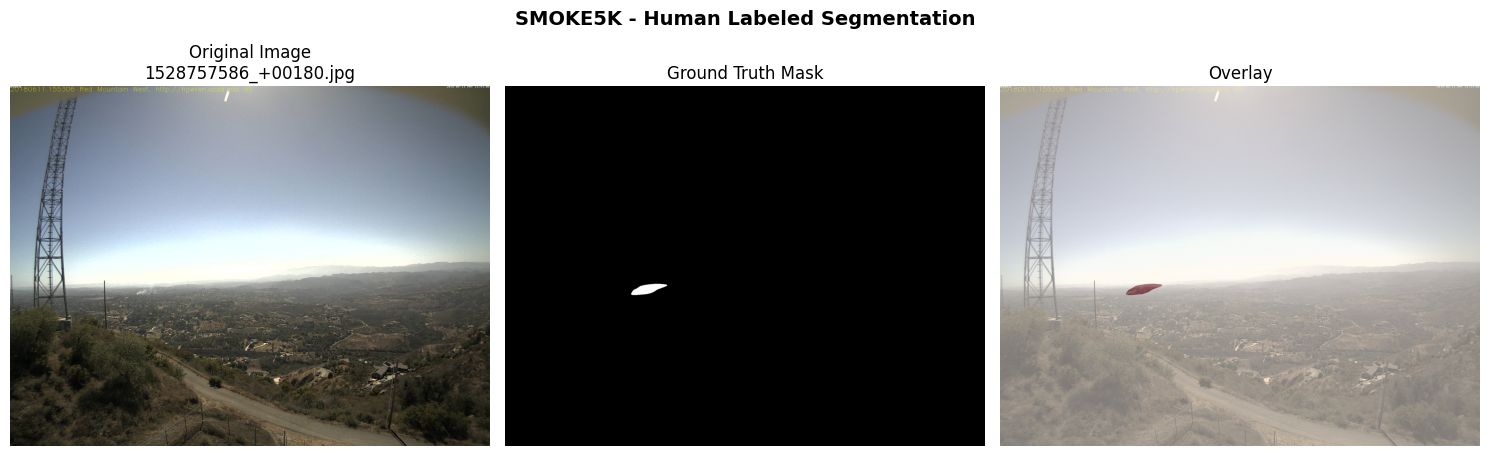

Total images in smoke5k/train: 5058


In [ ]:
# Smoke5k - Ground Truth Visualization
smoke5k_train_img_path = os.path.join(base_path, "smoke5k/train/img")
smoke5k_train_gt_path = os.path.join(base_path, "smoke5k/train/gt")

# Get a sample image
img_files = sorted(os.listdir(smoke5k_train_img_path))
sample_img_name = img_files[0]
sample_gt_name = sample_img_name.replace('.jpg', '.png')

img = Image.open(os.path.join(smoke5k_train_img_path, sample_img_name))
gt = Image.open(os.path.join(smoke5k_train_gt_path, sample_gt_name))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img)
axes[0].set_title(f"Original Image\n{sample_img_name}")
axes[0].axis('off')

axes[1].imshow(gt, cmap='gray')
axes[1].set_title("Ground Truth Mask")
axes[1].axis('off')

axes[2].imshow(img)
axes[2].imshow(np.array(gt), alpha=0.5, cmap='Reds')
axes[2].set_title("Overlay")
axes[2].axis('off')

plt.suptitle("SMOKE5K - Human Labeled Segmentation", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Total images in smoke5k/train: {len(img_files)}")

In [23]:
import hashlib
from PIL import Image
import os

# Function to compute image hash (checks if images are identical)
def get_image_hash(image_path):
    """Compute SHA256 hash of image file"""
    sha256_hash = hashlib.sha256()
    with open(image_path, "rb") as f:
        for byte_block in iter(lambda: f.read(4096), b""):
            sha256_hash.update(byte_block)
    return sha256_hash.hexdigest()

# Get all images from train and test directories
smoke5k_train_img_path = os.path.join(base_path, "smoke5k/train/img")
smoke5k_test_img_path = os.path.join(base_path, "smoke5k/test/img")

train_files = sorted(os.listdir(smoke5k_train_img_path))
test_files = sorted(os.listdir(smoke5k_test_img_path))

print(f"Train images: {len(train_files)}")
print(f"Test images: {len(test_files)}")
print(f"Total: {len(train_files) + len(test_files)}")

# Compute hashes for all images
print("\nComputing hashes for train images...")
train_hashes = {}
for fname in train_files:
    fpath = os.path.join(smoke5k_train_img_path, fname)
    try:
        h = get_image_hash(fpath)
        train_hashes[fname] = h
    except Exception as e:
        print(f"  Error hashing {fname}: {e}")

print("Computing hashes for test images...")
test_hashes = {}
for fname in test_files:
    fpath = os.path.join(smoke5k_test_img_path, fname)
    try:
        h = get_image_hash(fpath)
        test_hashes[fname] = h
    except Exception as e:
        print(f"  Error hashing {fname}: {e}")

# Find duplicates: same hash, different name
train_hash_to_names = {}
for fname, h in train_hashes.items():
    if h not in train_hash_to_names:
        train_hash_to_names[h] = []
    train_hash_to_names[h].append(('train', fname))

test_hash_to_names = {}
for fname, h in test_hashes.items():
    if h not in test_hash_to_names:
        test_hash_to_names[h] = []
    test_hash_to_names[h].append(('test', fname))

# Find hashes that appear in both train and test
duplicates = []
for h in train_hash_to_names:
    if h in test_hash_to_names:
        duplicates.append((h, train_hash_to_names[h], test_hash_to_names[h]))

print(f"\n{'='*70}")
print(f"RESULTS: Found {len(duplicates)} identical images in train and test sets")
print(f"{'='*70}")

if duplicates:
    for idx, (h, train_info, test_info) in enumerate(duplicates):
        print(f"\nDuplicate {idx+1}:")
        for split, fname in train_info:
            print(f"  {split}/img/{fname}")
        for split, fname in test_info:
            print(f"  {split}/img/{fname}")
else:
    print("✓ No identical images found between train and test sets!")
    print("  (Train and test sets are cleanly separated)")


Train images: 5058
Test images: 400
Total: 5458

Computing hashes for train images...
Computing hashes for test images...
Computing hashes for test images...

RESULTS: Found 1 identical images in train and test sets

Duplicate 1:
  train/img/ckb3uv42hu2cw0797ivwaxexz.jpg
  test/img/ckb3w841muf6l0797ng4sea57.jpg

RESULTS: Found 1 identical images in train and test sets

Duplicate 1:
  train/img/ckb3uv42hu2cw0797ivwaxexz.jpg
  test/img/ckb3w841muf6l0797ng4sea57.jpg


## 2. IJMOND_SEG Dataset (Roboflow Human-Annotated)
900 images with COCO-format polygon annotations

In [27]:
ijmond_seg_path = os.path.join(base_path, "ijmond_seg/test")

with open(os.path.join(ijmond_seg_path, "_annotations.coco.json"), 'r') as f:
    coco_data = json.load(f)

# Get first image with annotations
first_img_info = coco_data['images'][0]
img_id = first_img_info['id']
img_name = first_img_info['file_name']

annotations = [ann for ann in coco_data['annotations'] if ann['image_id'] == img_id]
len(annotations[0]['segmentation'][0])

56

In [29]:
with open(os.path.join(ijmond_seg_path, "_annotations.coco.json"), 'r') as f:
    coco_data = json.load(f)
coco_data.keys()

dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])

In [30]:
coco_data['categories']

[{'id': 0, 'name': 'smoke', 'supercategory': 'none'},
 {'id': 1, 'name': 'high-opacity-smoke', 'supercategory': 'smoke'},
 {'id': 2, 'name': 'low-opacity-smoke', 'supercategory': 'smoke'}]

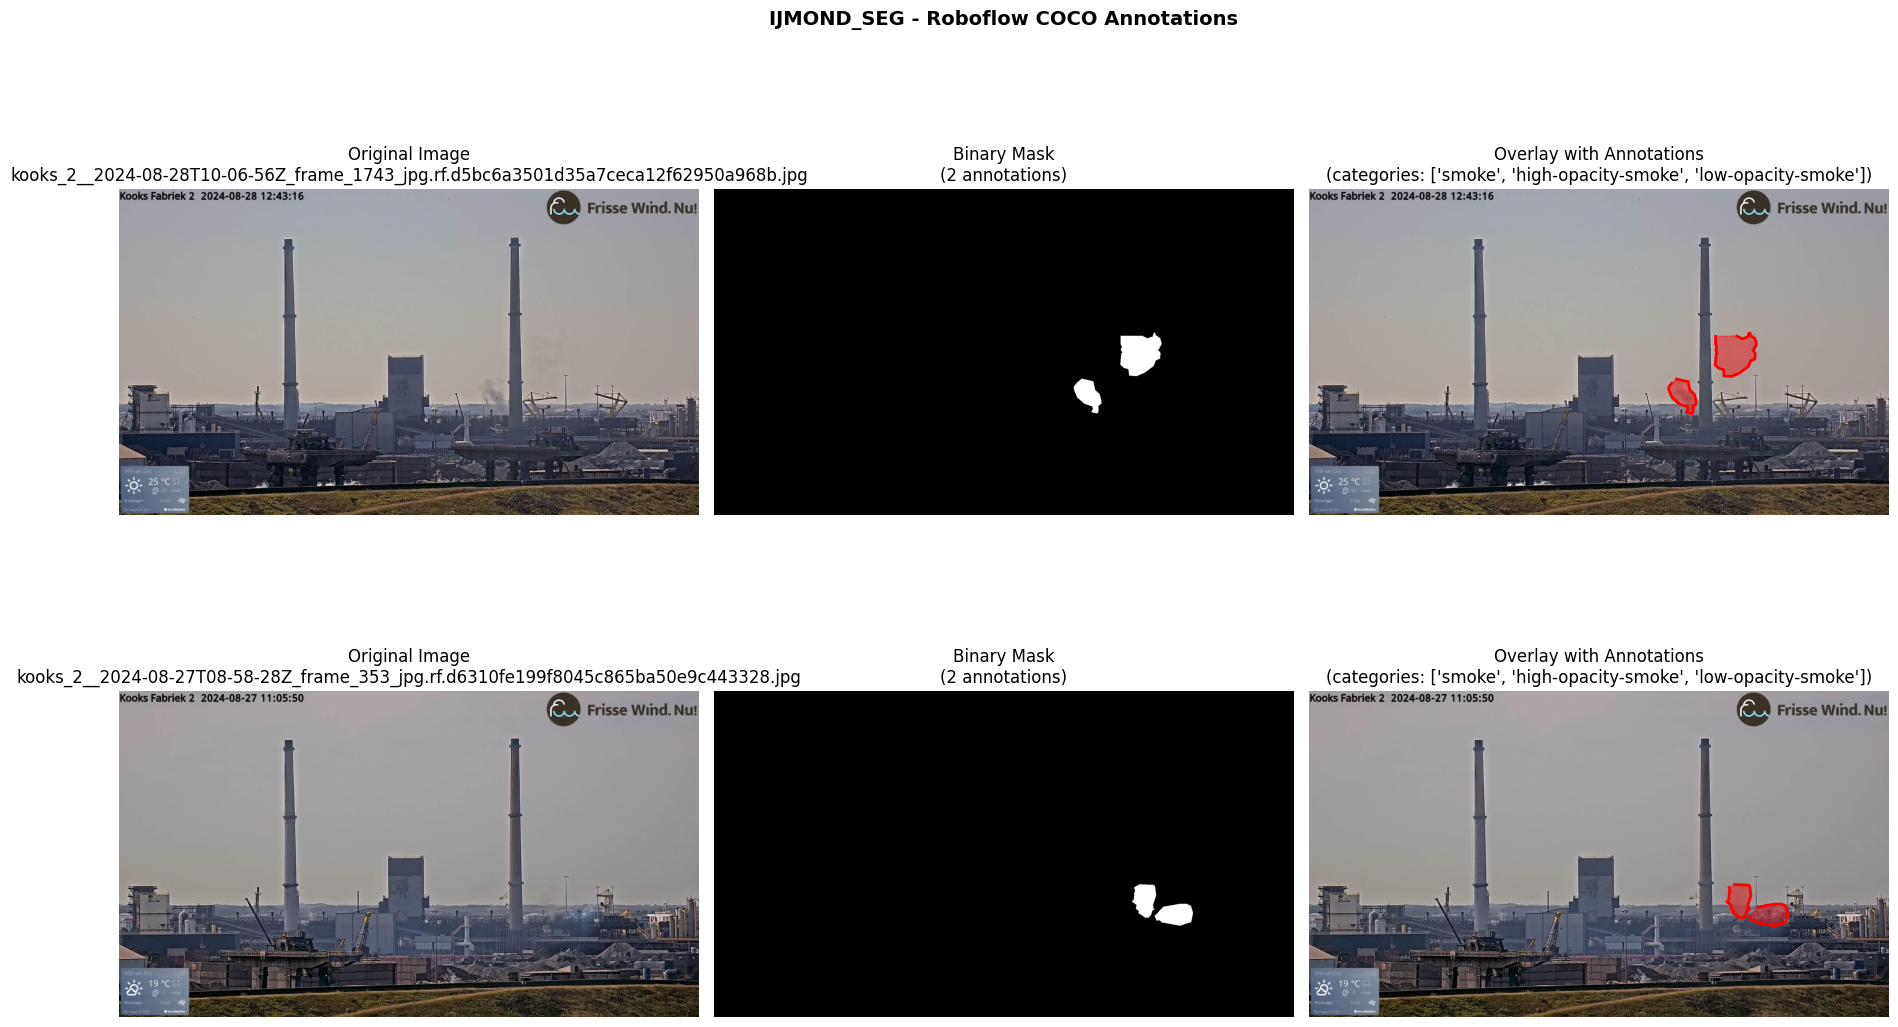

Total images: 900
Categories: ['smoke', 'high-opacity-smoke', 'low-opacity-smoke']


In [44]:
# IJmond_seg - COCO Format Visualization
ijmond_seg_path = os.path.join(base_path, "ijmond_seg/test")

with open(os.path.join(ijmond_seg_path, "_annotations.coco.json"), 'r') as f:
    coco_data = json.load(f)

# Get first image with annotations
samples_img_info = [coco_data['images'][i] for i in range(2)]
samples_img_id = [img['id'] for img in samples_img_info]
samples_img_name = [img['file_name'] for img in samples_img_info]

# Find annotations for this image
annotations = [[a for a in coco_data['annotations'] if a['image_id'] == samples_img_id[i]] for i in range(2)]

img = [Image.open(os.path.join(ijmond_seg_path, "images", samples_img_name[i])) for i in range(2)]

# Function to create binary mask from polygon annotations
def create_mask_from_polygons(image_shape, annotations):
    """Create binary mask from COCO polygon annotations"""
    from PIL import Image, ImageDraw
    mask = Image.new('L', image_shape, 0)
    draw = ImageDraw.Draw(mask)
    
    for ann in annotations:
        for poly in ann['segmentation']:
            # Convert flat list to list of tuples
            pts = [(poly[i], poly[i+1]) for i in range(0, len(poly), 2)]
            draw.polygon(pts, fill=255)
    
    return mask

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for i in range(2):
    # Get the single ID directly
    cat_id = next(img_info['id'] for img_info in coco_data['images'] if img_info['file_name'] == samples_img_name[i])

    # Get the single category name directly
    categories = [cat['name'] for cat in coco_data['categories']]
    
    # Original image
    axes[i, 0].imshow(img[i])
    axes[i, 0].set_title(f"Original Image\n{samples_img_name[i]}")
    axes[i, 0].axis('off')

    # Binary mask
    mask = create_mask_from_polygons(img[i].size, annotations[i])
    axes[i, 1].imshow(mask, cmap='gray')
    axes[i, 1].set_title(f"Binary Mask\n({len(annotations[i])} annotations)")
    axes[i, 1].axis('off')

    # Overlay with polygon annotations
    axes[i, 2].imshow(img[i])
    for ann in annotations[i]:
        seg = ann['segmentation']
        for poly in seg:
            pts = np.array(poly).reshape(-1, 2)
            axes[i, 2].fill(pts[:, 0], pts[:, 1], alpha=0.4, color='red')
            axes[i, 2].plot(pts[:, 0], pts[:, 1], 'r-', linewidth=2)
    axes[i, 2].set_title(f"Overlay with Annotations\n(categories: {categories})")
    axes[i, 2].axis('off')

plt.suptitle("IJMOND_SEG - Roboflow COCO Annotations", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Total images: {len(coco_data['images'])}")
print(f"Categories: {[c['name'] for c in coco_data['categories']]}")

## 3. IJMOND_PSEUDO_MASKS (SAM-Generated)
Pseudo masks automatically generated using SAM (Segment Anything Model) from bounding box prompts

Total images in ijmond_pseudo_masks/img: 610
0
<PIL.PngImagePlugin.PngImageFile image mode=RGB size=600x600 at 0x1F6FF5D10F0>
dataset\ijmond_pseudo_masks/mask\mask_img_0000_box_00.png
<PIL.PngImagePlugin.PngImageFile image mode=L size=600x600 at 0x1F6FF48DCD0>
1
<PIL.PngImagePlugin.PngImageFile image mode=RGB size=900x900 at 0x1F6FF5D3A80>
dataset\ijmond_pseudo_masks/mask\mask_img_0001_box_00.png
<PIL.PngImagePlugin.PngImageFile image mode=L size=900x900 at 0x1F6FF48DCD0>
2
<PIL.PngImagePlugin.PngImageFile image mode=RGB size=600x600 at 0x1F6FF5D10F0>
dataset\ijmond_pseudo_masks/mask\mask_img_0002_box_00.png
<PIL.PngImagePlugin.PngImageFile image mode=L size=600x600 at 0x1F6FF48DCD0>
3
<PIL.PngImagePlugin.PngImageFile image mode=RGB size=600x600 at 0x1F6FF5D3A80>
dataset\ijmond_pseudo_masks/mask\mask_img_0003_box_00.png
<PIL.PngImagePlugin.PngImageFile image mode=L size=600x600 at 0x1F6FF48DCD0>
4
<PIL.PngImagePlugin.PngImageFile image mode=RGB size=600x600 at 0x1F6FF5D10F0>
dataset\ij

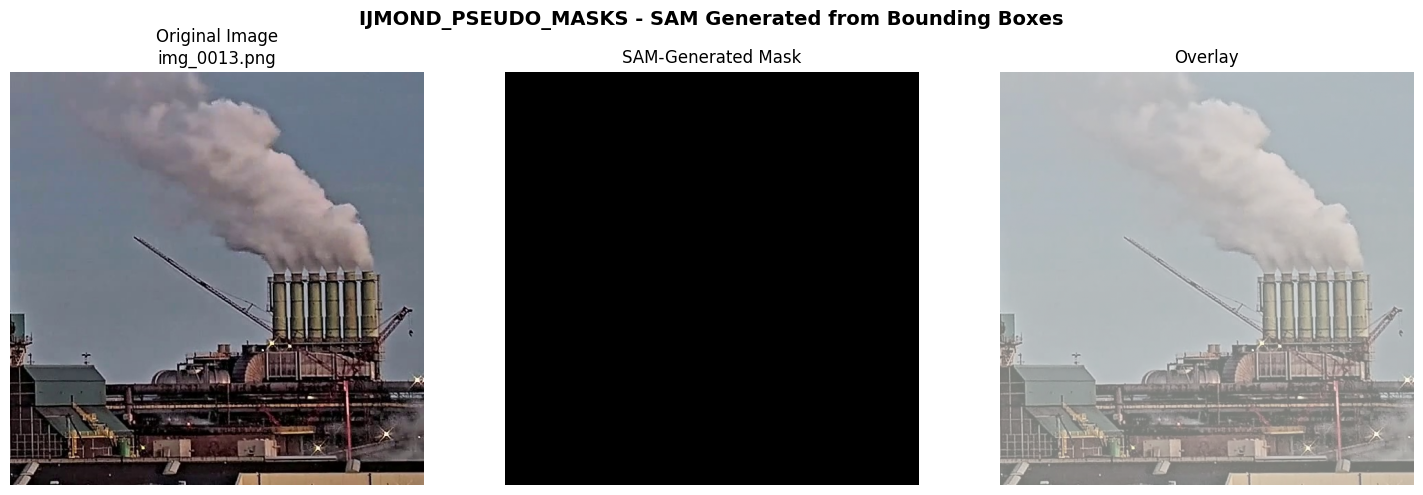

In [96]:
# IJmond Pseudo Masks - SAM Generated
pseudo_img_path = os.path.join(base_path, "ijmond_pseudo_masks/img")
pseudo_mask_path = os.path.join(base_path, "ijmond_pseudo_masks/mask")


index = 0 
mask_not_found = True
img_files = sorted(os.listdir(pseudo_img_path))
print(f"Total images in ijmond_pseudo_masks/img: {len(img_files)}")
while mask_not_found and index < len(img_files):
    print(index)
    sample_name = img_files[index]

    img = Image.open(os.path.join(pseudo_img_path, sample_name))
    print(img)

    # Robustly find corresponding mask file (match by stem, allow different extensions)
    mask = None
    sample_mask_name = "mask_" + sample_name[:-4] + "_box_00.png"
    expected_mask_path = os.path.join(pseudo_mask_path, sample_mask_name)
    print(expected_mask_path)
    if os.path.exists(expected_mask_path):
        mask = Image.open(expected_mask_path)
        print(mask)
    else:
        base_name, _ = os.path.splitext(sample_name)
        if os.path.isdir(pseudo_mask_path):
            mask_candidates = [f for f in os.listdir(pseudo_mask_path) if os.path.splitext(f)[0] == base_name]
            if mask_candidates:
                mask = Image.open(os.path.join(pseudo_mask_path, mask_candidates[0]))
        # try common extensions as a last resort
        if mask is None:
            for ext in (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"):
                p = os.path.join(pseudo_mask_path, base_name + ext)
                if os.path.exists(p):
                    mask = Image.open(p)
                    break

    

    if mask is not None and sample_name == 'img_0013.png':
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(img)
        axes[0].set_title(f"Original Image\n{sample_name}")
        axes[0].axis('off')
        axes[1].imshow(mask, cmap='gray')
        axes[1].set_title("SAM-Generated Mask")
        axes[1].axis('off')

        axes[2].imshow(img)
        axes[2].imshow(np.array(mask), alpha=0.5, cmap='Greens')
        axes[2].set_title("Overlay")
        axes[2].axis('off')
        plt.suptitle("IJMOND_PSEUDO_MASKS - SAM Generated from Bounding Boxes", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        mask_not_found = False
    #else:
    #    axes[1].text(0.5, 0.5, "Mask not found", ha='center', va='center', fontsize=12)
    #    axes[1].set_title("SAM-Generated Mask")
    #    axes[1].axis('off')

    #    axes[2].imshow(img)
    #    axes[2].set_title("Overlay\n(no mask)")
    #    axes[2].axis('off')

    index += 1

    


In [100]:
import numpy as np
import os

folder_path = r'dataset/ijmond_pseudo_masks/mask_npy'
black_count = 0
bw_count = 0

for filename in os.listdir(folder_path):
    if filename.endswith('.npy'):
        file_path = os.path.join(folder_path, filename)
        
        # Load the array
        img_array = np.load(file_path)
        
        # Check if any pixel is non-zero
        if np.any(img_array):
            bw_count += 1
        else:
            black_count += 1

print(f"Total .npy files: {black_count + bw_count}")
print(f"Completely Black: {black_count}")
print(f"Contains White/Content: {bw_count}")

Total .npy files: 610
Completely Black: 420
Contains White/Content: 190


## 4. IJMOND_BBOX (Citizen Science Bounding Box Labels)
Raw images with bounding box annotations from IJmondCAM citizen science tool

In [57]:
# IJmond BBox - Citizen Science Bounding Boxes
bbox_img_path = os.path.join(base_path, "ijmond_bbox/img")
bbox_label_path = os.path.join(base_path, "ijmond_bbox/bbox_labels_1_aug_2025.json")

with open(bbox_label_path, 'r') as f:
    bbox_data = json.load(f)

# Find an image with bounding boxes
sample_entry = None

bbox_data['data'][0].keys()

dict_keys(['feedback_filtered', 'file_path', 'frame_number', 'frame_timestamp', 'h_bbox', 'h_image', 'id', 'image_file_name', 'label_state', 'label_state_admin', 'label_update_time', 'mask_file_name', 'url_root', 'video', 'w_bbox', 'w_image', 'x_bbox', 'y_bbox'])

In [60]:
bbox_data['data'][0]

{'feedback_filtered': [],
 'file_path': 'bbox_batch_2/B6goTCxdTmI-1/29/B6goTCxdTmI-1-29-2/',
 'frame_number': 29,
 'frame_timestamp': 1678104931,
 'h_bbox': 18,
 'h_image': 600,
 'id': 1,
 'image_file_name': 'crop.png',
 'label_state': -1,
 'label_state_admin': -1,
 'label_update_time': 1742819237,
 'mask_file_name': 'mask.png',
 'url_root': 'https://ijmondcam.multix.io/videos/',
 'video': {'camera_id': 1,
  'file_name': 'B6goTCxdTmI-1',
  'id': 312,
  'url_part': 'B6goTCxdTmI',
  'view_id': 1},
 'w_bbox': 20,
 'w_image': 600,
 'x_bbox': 226,
 'y_bbox': 272}

In [65]:
# Search directly in the list
matching_id = next((item['id'] for item in bbox_data['data'] if item.get('label_state') == 3), None)

if matching_id:
    print(f"Found ID: {matching_id}")
else:
    print("No entry found with label_state 16.")

Found ID: 307


In [51]:
entry_1079 = next((entry for entry in bbox_data if entry['id'] == 1079), None)
entry_1079.get('label_state') if entry_1079 else None

In [12]:
bbox_data['data'][0]['video']

{'camera_id': 1,
 'file_name': 'B6goTCxdTmI-1',
 'id': 312,
 'url_part': 'B6goTCxdTmI',
 'view_id': 1}

In [46]:
sample_entry

{'id': 1079,
 'bbox': [{'x_bbox': 241,
   'y_bbox': 238,
   'w_bbox': 274,
   'h_bbox': 361,
   'h_image': 600,
   'w_image': 600}]}

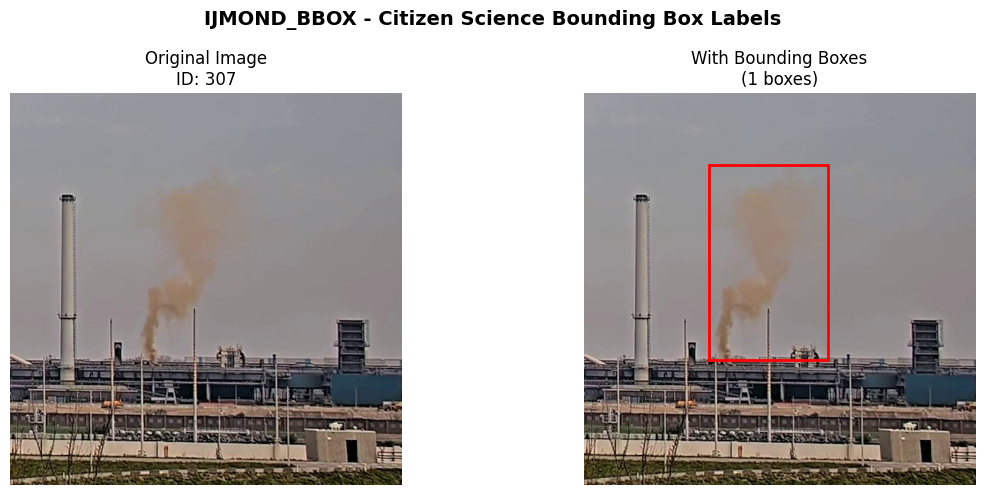

Total entries in bbox JSON: 610
Entries with bboxes: 190


In [103]:
# IJmond BBox - Citizen Science Bounding Boxes
bbox_img_path = os.path.join(base_path, "ijmond_bbox/img")
bbox_label_path = os.path.join(base_path, "ijmond_bbox/filtered_bbox_labels_1_aug_2025.json")

with open(bbox_label_path, 'r') as f:
    bbox_data = json.load(f)



#for i in range(10)
# Find an image with bounding boxes
sample_entry = None
for entry in bbox_data:
    if entry.get('id') == 307:
        sample_entry = entry
        break

if sample_entry:
    img_name = f"{sample_entry['id']}.png"
    img = Image.open(os.path.join(bbox_img_path, img_name))
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(img)
    axes[0].set_title(f"Original Image\nID: {sample_entry['id']}")
    axes[0].axis('off')
    
    axes[1].imshow(img)
    for bbox in sample_entry['bbox']:
        # Use the correct key names: x_bbox, y_bbox, w_bbox, h_bbox
        x, y, w, h = bbox['x_bbox'], bbox['y_bbox'], bbox['w_bbox'], bbox['h_bbox']
        rect = plt.Rectangle((x, y), w, h, fill=False, color='red', linewidth=2)
        axes[1].add_patch(rect)
    axes[1].set_title(f"With Bounding Boxes\n({len(sample_entry['bbox'])} boxes)")
    axes[1].axis('off')
    
    plt.suptitle("IJMOND_BBOX - Citizen Science Bounding Box Labels", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"Total entries in bbox JSON: {len(bbox_data)}")
    print(f"Entries with bboxes: {sum(1 for e in bbox_data if e.get('bbox') and len(e['bbox']) > 0)}")